In [1]:
import os
import sys

%load_ext autoreload
%autoreload 2
%aimport connectivity

date                                 2023-11-22
h                                            22
min                                          24
s                                             6
us                                        68317
type                                      CR_BM
run                                     success
stim_block                                    3
StimNum                                     481
ChanP                                        31
ChanN                                        32
ISI_s                                  4.510225
Int_prob                                    3.0
Int_cond                                    0.0
IPI_ms                                      0.0
currentflow                               100.0
datetime       2023-11-22 22:24:06.068317+00:00
name_pos                                 OF-R-3
name_neg                                 OF-R-4
time_diff                              4.746311
TTL                                     

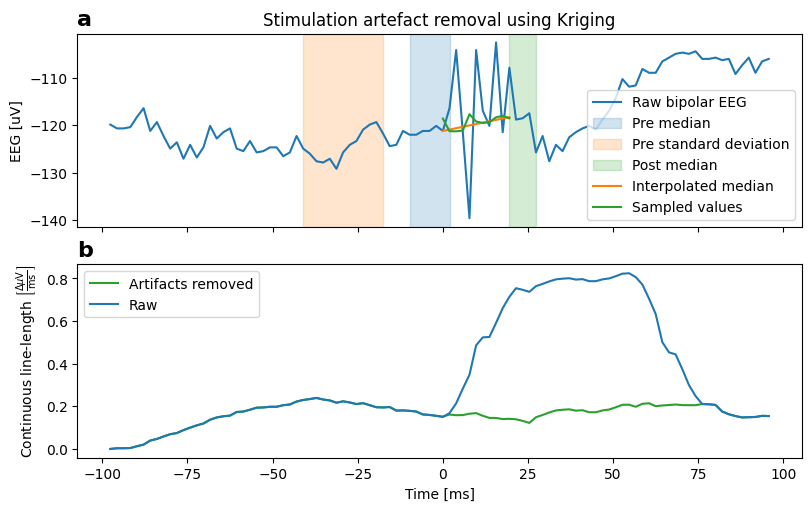

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

from connectivity.load import HDFResponseLoader
from connectivity.analyze import (
    calculate_continuous_line_length,
    calculate_stimulation_response_curves,
)

name_h5 = "EL028_20231122_19h49m35_CR"

stimlist = pd.read_csv(f"D:/data/EL028/out/{name_h5}_logs.csv")[0:]

stim_id = "CR_BM-1972"
stim_index = stimlist[stimlist["stim_id"] == stim_id].index[0]
stimulation = stimlist.loc[stim_index]
print(stimulation)
channels = ["traces/raw/pH_R4", "traces/raw/pH_R5"]
print(stim_index)

rl = HDFResponseLoader(
    path_h5=f"D:/data/EL028/Electrophy/{name_h5}.h5",
    path_logs=f"D:/data/EL028/out/{name_h5}_logs.csv",
    path_lookup="D:/data/EL028/Electrodes/Lookup.xlsx",
)

io_stimlist = stimlist

traces = rl.get_data(
    dataset_paths=channels,
    start_row_index=stimulation["TTL"] - 50,
    end_row_index=stimulation["TTL"] + 50,
).to_numpy()


bipolar_trace = traces[:, 0] - traces[:, 1]
window_stimulation_offset = np.round(np.array([0.002, 0.017]) * rl.f_sample).astype(int)
peak_index = 51

cont_ll = calculate_continuous_line_length(
    data=bipolar_trace,
    f_sample=rl.f_sample,
    start_index=0,
    end_index=len(bipolar_trace),
    window_width_indices=round(0.250 * rl.f_sample),
)

artifact_length = np.sum(window_stimulation_offset) + 1
pre_median = np.median(
    bipolar_trace[
        peak_index
        - window_stimulation_offset[0]
        - 5 : peak_index
        - window_stimulation_offset[0]
        + 1
    ]
)
pre_std = np.std(
    bipolar_trace[
        peak_index
        - window_stimulation_offset[0]
        - artifact_length
        - 10 : peak_index
        - window_stimulation_offset[0]
        - 10
        + 1
    ]
)
post_median = np.median(
    bipolar_trace[
        peak_index
        + window_stimulation_offset[1] : peak_index
        + window_stimulation_offset[1]
        + 4
    ]
)

t = (np.arange(len(bipolar_trace)) - 50) / rl.f_sample * 1000

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]  # Extract colors from cycle


fig = plt.figure(figsize=(8, 5), constrained_layout=True)
gs = gridspec.GridSpec(2, 1, figure=fig)

ax_u = fig.add_subplot(gs[0, 0])
ax_l = fig.add_subplot(gs[1, 0])

ax_u.plot(t, bipolar_trace, label="Raw bipolar EEG")
ax_u.axvspan(
    t[peak_index - window_stimulation_offset[0] - 5],
    t[peak_index - window_stimulation_offset[0] + 1],
    label="Pre median",
    alpha=0.2,
    color=colors[0],
)
ax_u.axvspan(
    t[peak_index - window_stimulation_offset[0] - artifact_length - 10],
    t[peak_index - window_stimulation_offset[0] - 10 + 1],
    label="Pre standard deviation",
    alpha=0.2,
    color=colors[1],
)
ax_u.axvspan(
    t[peak_index + window_stimulation_offset[1]],
    t[peak_index + window_stimulation_offset[1] + 4],
    label="Post median",
    alpha=0.2,
    color=colors[2],
)

factor = 3
res = np.linspace(pre_median, post_median, num=artifact_length, endpoint=False)


ax_u.plot(
    t[
        peak_index
        - window_stimulation_offset[0] : peak_index
        + window_stimulation_offset[1]
        + 1
    ],
    res,
    label="Interpolated median",
)

res += np.random.normal(loc=0, scale=pre_std / factor, size=res.shape)

preprocessed_trace = bipolar_trace.copy()
preprocessed_trace[
    peak_index
    - window_stimulation_offset[0] : peak_index
    + window_stimulation_offset[1]
    + 1
] = res

preprocessed_cont_ll = calculate_continuous_line_length(
    data=preprocessed_trace,
    f_sample=rl.f_sample,
    start_index=0,
    end_index=len(preprocessed_trace),
    window_width_indices=round(0.250 * rl.f_sample),
)


ax_u.plot(
    t[
        peak_index
        - window_stimulation_offset[0] : peak_index
        + window_stimulation_offset[1]
        + 1
    ],
    res,
    label="Sampled values",
)
ax_u.set_ylabel("EEG [uV]")
ax_u.set_title("Stimulation artefact removal using Kriging")
ax_u.set_title("a", loc='left', fontsize=16, fontweight='bold')
ax_u.legend()
plt.setp(ax_u.get_xticklabels(), visible=False)

ax_l.plot(t, preprocessed_cont_ll, label="Artifacts removed", color=colors[2])
ax_l.plot(t, cont_ll, color=colors[0], label="Raw")
ax_l.set_title("b", loc='left', fontsize=16, fontweight='bold')
ax_l.set_ylabel("Continuous line-length $\\left[\\frac{\\Delta\\mu \\mathrm{V}}{\\mathrm{ms}}\\right]$")
ax_l.set_xlabel("Time [ms]")
ax_l.legend()

plt.savefig("../output/figures/sfigure3.pdf", bbox_inches="tight", dpi=300)
plt.savefig("../output/figures/sfigure3.svg", bbox_inches="tight", dpi=300)
plt.show()